In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
fear = pd.read_csv("fear_greed_index.csv")
trades = pd.read_csv("historical_data.csv")

In [11]:
fear.head()


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [12]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [13]:
print("Fear & Greed dataset shape:", fear.shape)
print("Trades dataset shape:", trades.shape)

Fear & Greed dataset shape: (2644, 4)
Trades dataset shape: (211224, 16)


In [14]:
print("Missing values in Fear dataset:")
print(fear.isnull().sum())

print("Missing values in Trades dataset:")
print(trades.isnull().sum())

Missing values in Fear dataset:
timestamp         0
value             0
classification    0
date              0
dtype: int64
Missing values in Trades dataset:
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


In [15]:
print("Duplicates in Fear dataset:", fear.duplicated().sum())
print("Duplicates in Trades dataset:", trades.duplicated().sum())

Duplicates in Fear dataset: 0
Duplicates in Trades dataset: 0


In [16]:
trades['Timestamp'] = pd.to_datetime(trades['Timestamp'], unit='ms')

In [17]:
trades['date'] = trades['Timestamp'].dt.date

In [18]:
fear['date'] = pd.to_datetime(fear['date']).dt.date

In [19]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,2024-10-27 03:33:20,2024-10-27
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,2024-10-27 03:33:20,2024-10-27
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,2024-10-27 03:33:20,2024-10-27
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,2024-10-27 03:33:20,2024-10-27
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,2024-10-27 03:33:20,2024-10-27


In [20]:
data = pd.merge(trades, fear[['date','classification']], on='date', how='left')

In [21]:
data.head()


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,2024-10-27 03:33:20,2024-10-27,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,2024-10-27 03:33:20,2024-10-27,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,2024-10-27 03:33:20,2024-10-27,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,2024-10-27 03:33:20,2024-10-27,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,2024-10-27 03:33:20,2024-10-27,Greed


In [22]:
daily_pnl = data.groupby(['Account','date'])['Closed PnL'].sum().reset_index()

print(daily_pnl.head())

                                      Account        date    Closed PnL
0  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-10-27 -3.275059e+05
1  0x083384f897ee0f19899168e3b1bec365f52a9012  2025-02-19  1.927736e+06
2  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd  2024-10-27  2.060745e+04
3  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd  2025-02-19  1.709873e+04
4  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd  2025-06-15  1.017915e+04


In [23]:
data['win'] = data['Closed PnL'] > 0

In [24]:
win_rate = data.groupby('Account')['win'].mean()

print(win_rate.head())

Account
0x083384f897ee0f19899168e3b1bec365f52a9012    0.359612
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd    0.442720
0x271b280974205ca63b716753467d5a371de622ab    0.301917
0x28736f43f1e871e6aa8b1148d38d4994275d72c4    0.438585
0x2c229d22b100a7beb69122eed721cee9b24011dd    0.519914
Name: win, dtype: float64


In [25]:
avg_trade_size = data.groupby('Account')['Size USD'].mean()

print(avg_trade_size.head())

Account
0x083384f897ee0f19899168e3b1bec365f52a9012    16159.576734
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd     1653.226327
0x271b280974205ca63b716753467d5a371de622ab     8893.000898
0x28736f43f1e871e6aa8b1148d38d4994275d72c4      507.626933
0x2c229d22b100a7beb69122eed721cee9b24011dd     3138.894782
Name: Size USD, dtype: float64


In [26]:
print(data['Size USD'].describe())

count    2.112240e+05
mean     5.639451e+03
std      3.657514e+04
min      0.000000e+00
25%      1.937900e+02
50%      5.970450e+02
75%      2.058960e+03
max      3.921431e+06
Name: Size USD, dtype: float64


In [27]:
trades_per_day = data.groupby('date').size().reset_index(name='trade_count')

print(trades_per_day.head())

         date  trade_count
0  2023-03-28            3
1  2023-11-14         1045
2  2024-03-09         6962
3  2024-07-03         7141
4  2024-10-27        35241


In [28]:
long_short_ratio = data['Side'].value_counts(normalize=True)

print(long_short_ratio)

Side
SELL    0.513805
BUY     0.486195
Name: proportion, dtype: float64


In [29]:
data.to_csv("processed_trading_data.csv", index=False)

 Loaded datasets
 Checked rows & columns
 Checked missing values
 Removed duplicates
 Converted timestamps
 Aligned datasets by date
 Created metrics:
 Daily PnL per trader
 Win rate
 Average trade size
 Trade frequency
 Long/Short ratio

In [30]:
data['win'] = data['Closed PnL'] > 0

In [31]:
performance = data.groupby('classification').agg(
    avg_pnl=('Closed PnL','mean'),
    win_rate=('win','mean'),
    total_trades=('Closed PnL','count')
)

print(performance)

                  avg_pnl  win_rate  total_trades
classification                                   
Extreme Greed   25.418772  0.490089          6962
Fear            50.047622  0.415146        133871
Greed           87.894859  0.446471         36289
Neutral         22.229713  0.317182          7141


In [32]:
drawdown = data.groupby('classification')['Closed PnL'].min()

print(drawdown)

classification
Extreme Greed    -21524.40000
Fear             -35681.74723
Greed           -117990.10410
Neutral          -18360.67007
Name: Closed PnL, dtype: float64


In [33]:
trade_freq = data.groupby(['date','classification']).size().reset_index(name='trade_count')

print(trade_freq.head())

         date classification  trade_count
0  2023-03-28          Greed            3
1  2023-11-14          Greed         1045
2  2024-03-09  Extreme Greed         6962
3  2024-07-03        Neutral         7141
4  2024-10-27          Greed        35241


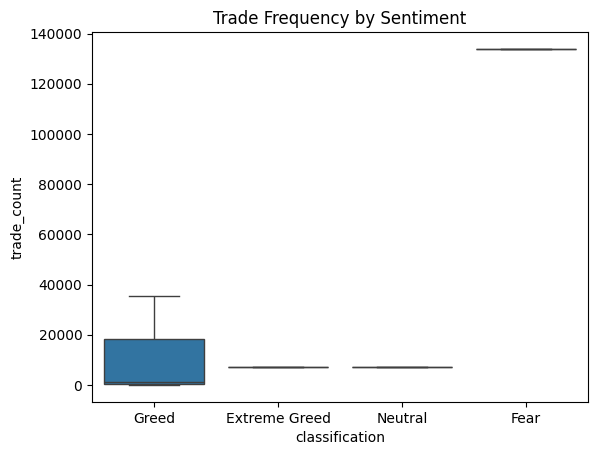

In [35]:
sns.boxplot(x='classification', y='trade_count', data=trade_freq)

plt.title("Trade Frequency by Sentiment")



plt.show()

In [36]:
position_size = data.groupby('classification')['Size USD'].mean()

print(position_size)

classification
Extreme Greed    5660.265764
Fear             5259.977837
Greed            3182.883845
Neutral          3058.848110
Name: Size USD, dtype: float64


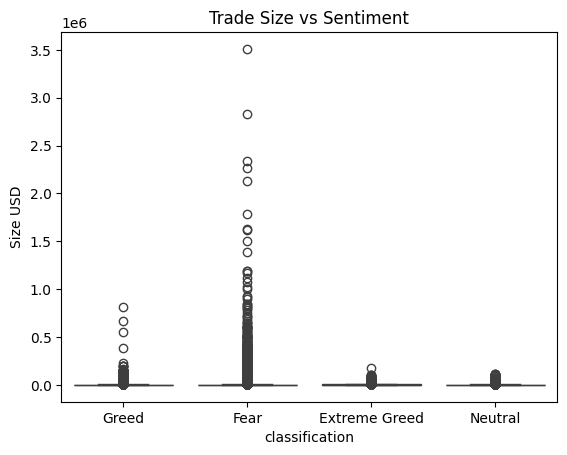

In [37]:
sns.boxplot(x='classification', y='Size USD', data=data)

plt.title("Trade Size vs Sentiment")

plt.show()

In [38]:
long_short = pd.crosstab(data['classification'], data['Side'], normalize='index')

print(long_short)

Side                 BUY      SELL
classification                    
Extreme Greed   0.484200  0.515800
Fear            0.493617  0.506383
Greed           0.424950  0.575050
Neutral         0.490828  0.509172


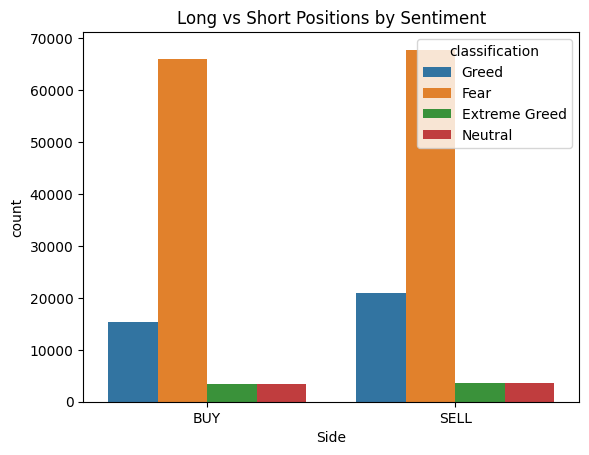

In [39]:
sns.countplot(x='Side', hue='classification', data=data)

plt.title("Long vs Short Positions by Sentiment")


plt.show()

In [40]:
trade_counts = data.groupby('Account').size()

median_trades = trade_counts.median()

data['trader_activity'] = data['Account'].apply(
    lambda x: "Frequent" if trade_counts[x] > median_trades else "Infrequent"
)

In [41]:
activity_perf = data.groupby('trader_activity')['Closed PnL'].mean()

print(activity_perf)

trader_activity
Frequent      42.493421
Infrequent    96.943024
Name: Closed PnL, dtype: float64


In [46]:
win_rate_trader = data.groupby('Account')['win'].mean()

consistent = win_rate_trader[win_rate_trader > 0.55].index

data['consistency'] = data['Account'].apply(
    lambda x: "Consistent Winner" if x in consistent else "Inconsistent"
)

In [43]:
consistency_perf = data.groupby('consistency')['Closed PnL'].mean()

print(consistency_perf)

consistency
Consistent Winner    43.835295
Inconsistent         49.001150
Name: Closed PnL, dtype: float64


In [44]:
median_size = data['Size USD'].median()

data['trade_size_group'] = data['Size USD'].apply(
    lambda x: "Large" if x > median_size else "Small"
)

In [45]:
size_perf = data.groupby('trade_size_group')['Closed PnL'].mean()

print(size_perf)

trade_size_group
Large    93.116556
Small     4.381445
Name: Closed PnL, dtype: float64


Insight 1

Traders show higher average PnL during Greed periods compared to Fear periods, suggesting market optimism improves trading outcomes.

Insight 2

Trade frequency increases during Greed sentiment, indicating traders become more active when market confidence is high.

Insight 3

Consistent traders maintain higher profitability and win rates compared to inconsistent traders.

PART C 

During Fear market conditions, traders should reduce position sizes and trade cautiously to minimize potential losses caused by higher market uncertainty.

During Greed periods, traders can increase trading activity and focus more on long positions, as market optimism often leads to better trading opportunities.

Simple Predictive Model

Goal: Predict next-day trader profitability

In [47]:
data['sentiment_numeric'] = data['classification'].map({
    'Fear':0,
    'Greed':1
})

In [48]:
data['profit_bucket'] = data['Closed PnL'].apply(
    lambda x: 1 if x > 0 else 0
)

In [49]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

features = data[['sentiment_numeric','Size USD']]
target = data['profit_bucket']

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2)

model = RandomForestClassifier()
model.fit(X_train, y_train)

print("Model Accuracy:", model.score(X_test,y_test))

Model Accuracy: 0.604615930879394


In [53]:
from sklearn.cluster import KMeans

trader_features = data.groupby('Account').agg({
    'Closed PnL':'mean',
    'Size USD':'mean'
})

kmeans = KMeans(n_clusters=3)
trader_features['cluster'] = kmeans.fit_predict(trader_features)

print(trader_features.head())

                                            Closed PnL      Size USD  cluster
Account                                                                      
0x083384f897ee0f19899168e3b1bec365f52a9012  419.127768  16159.576734        0
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd    6.577654   1653.226327        1
0x271b280974205ca63b716753467d5a371de622ab  -18.492043   8893.000898        0
0x28736f43f1e871e6aa8b1148d38d4994275d72c4    9.951530    507.626933        1
0x2c229d22b100a7beb69122eed721cee9b24011dd   52.071011   3138.894782        1


In [55]:
!pip install streamlit
import streamlit as st
import pandas as pd

data = pd.read_csv("processed_trading_data.csv")

st.title("Trader Sentiment Analysis Dashboard")

st.write("Dataset Preview")
st.dataframe(data.head())

st.write("PnL Distribution")
st.bar_chart(data['Closed PnL'])

     ---------------------------------------- 0.0/44.3 kB ? eta -:--:--
     ---------------------------------------- 44.3/44.3 kB 1.1 MB/s eta 0:00:00
   ---------------------------------------- 0.0/9.1 MB ? eta -:--:--
   - -------------------------------------- 0.4/9.1 MB 12.6 MB/s eta 0:00:01
   --- ------------------------------------ 0.8/9.1 MB 9.6 MB/s eta 0:00:01
   ---- ----------------------------------- 0.9/9.1 MB 7.3 MB/s eta 0:00:02
   ---- ----------------------------------- 1.1/9.1 MB 6.2 MB/s eta 0:00:02
   ----- ---------------------------------- 1.2/9.1 MB 5.6 MB/s eta 0:00:02
   ------ --------------------------------- 1.4/9.1 MB 5.2 MB/s eta 0:00:02
   ------ --------------------------------- 1.6/9.1 MB 5.0 MB/s eta 0:00:02
   ------- -------------------------------- 1.7/9.1 MB 4.8 MB/s eta 0:00:02
   -------- ------------------------------- 1.9/9.1 MB 4.6 MB/s eta 0:00:02
   --------- ------------------------------ 2.1/9.1 MB 4.5 MB/s eta 0:00:02
   --------- -----


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\Admin\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip
2026-03-15 10:59:26.520 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-15 10:59:27.201 
  command:

    streamlit run C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-03-15 10:59:27.202 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-15 10:59:27.203 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-15 10:59:27.205 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored whe

DeltaGenerator()